In [57]:
import pandas as pd
import matplotlib.pyplot as plt


In [58]:

datos_arbolado= pd.read_pickle("../data/datos_arbolado")

datos_arbolado.head()

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol,ancho_acera_limpio
0,-58.378563,-34.594902,1,NaN,Esmeralda,1000.0,1120.0,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0,5.5
1,-58.381532,-34.592319,1,NaN,Pellegrini Carlos,1300.0,1345.0,Peltophorum dubium,4.5,2.0,Regular,2.0,6.0,5.0,4.5
2,-58.379103,-34.591939,1,NaN,Arroyo,800.0,848.0,Fraxinus pennsylvanica,4,2.0,Regular,1.0,7.0,6.0,4.0
3,-58.380710,-34.591548,1,NaN,Arroyo,900.0,932.0,Fraxinus pennsylvanica,NaN,2.0,Regular,1.0,9.0,29.0,NaN
4,-58.380710,-34.591548,1,NaN,Arroyo,900.0,932.0,Jacaranda mimosifolia,NaN,2.0,Regular,1.0,13.0,8.0,NaN


# Las comunas con mayor densidad de arboles tambien experimentan mayor densidad sobreocupacion.

In [59]:
estado_plantera=datos_arbolado['estado_plantera'].value_counts()
print(estado_plantera)

estado_plantera
2.0    330898
3.0     38549
1.0       532
0.0         4
Name: count, dtype: int64


/tmp/ipykernel_43031/2916392440.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab20', len(categorias))
/tmp/ipykernel_43031/2916392440.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(markerscale=9)


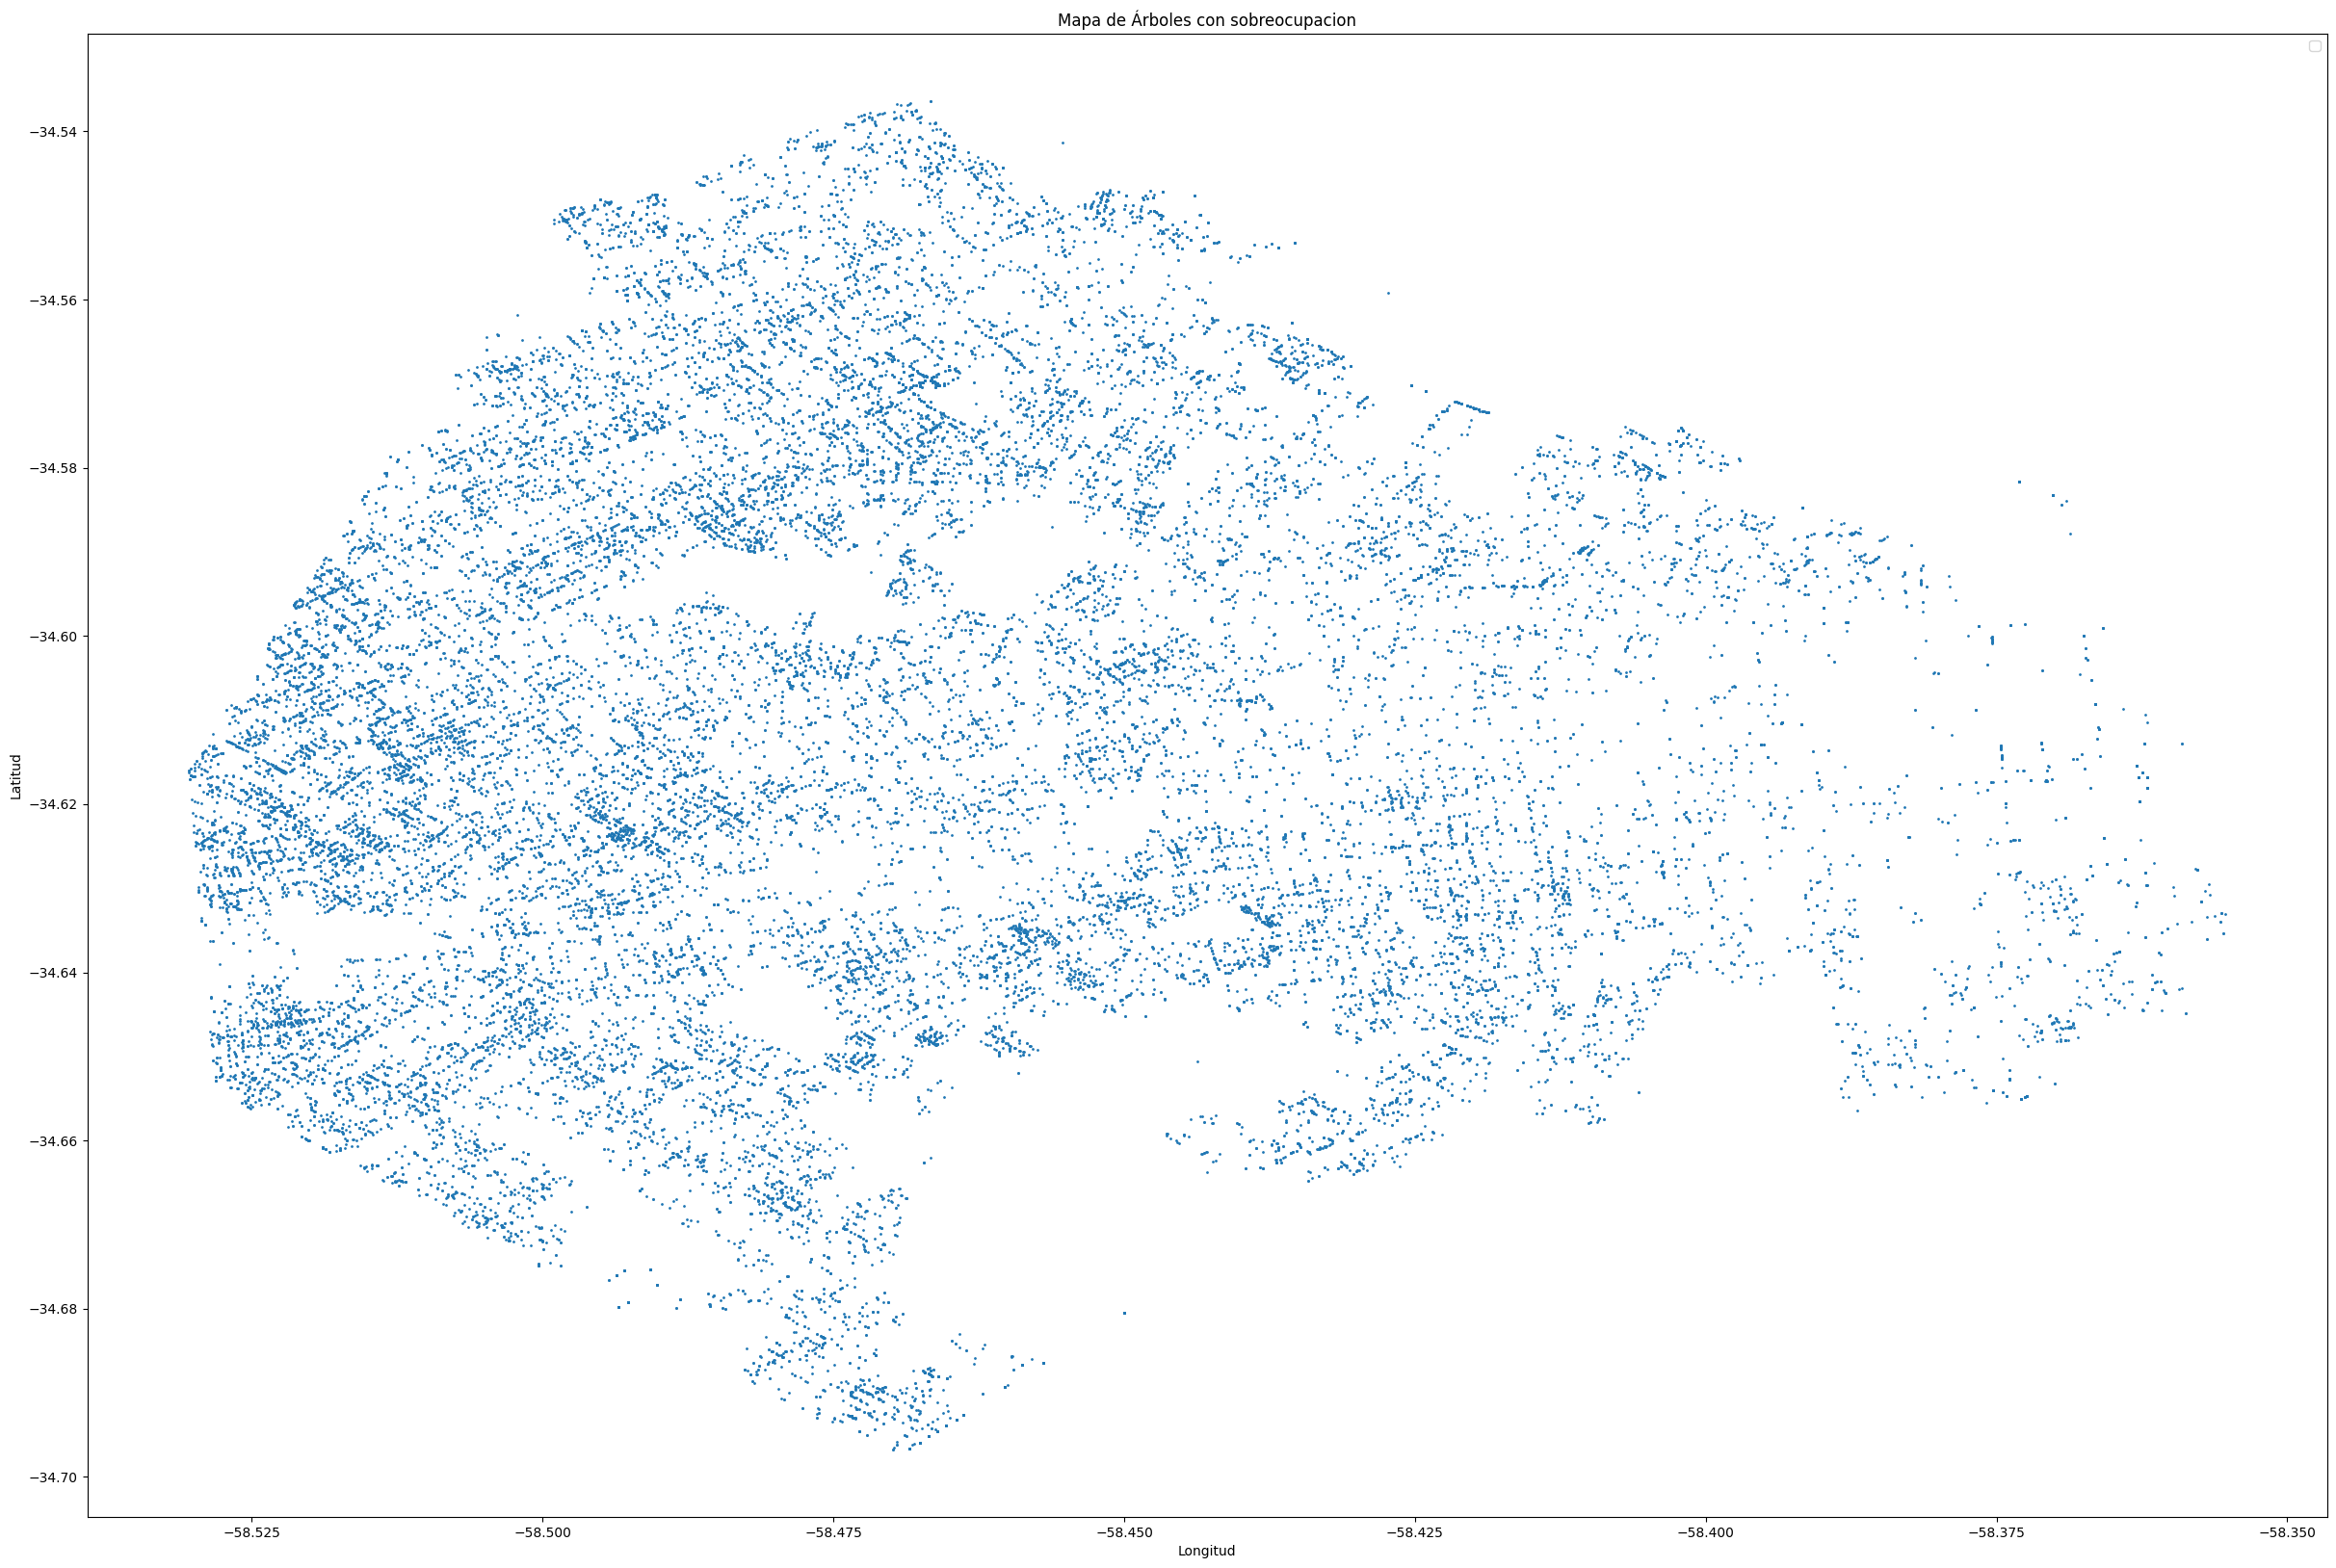

In [60]:
plt.figure(figsize=(30, 20))
categorias = sorted(estado_plantera.index)
colores = plt.cm.get_cmap('tab20', len(categorias))
subset = datos_arbolado[datos_arbolado['estado_plantera'] == 3]
plt.scatter(
    subset['long'],
    subset['lat'],
    s=1,
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de Árboles con sobreocupacion")
plt.legend(markerscale=9)
plt.show()

In [61]:
sobreocupacion_comunas= datos_arbolado[(datos_arbolado['comuna']<=11) & (datos_arbolado['comuna']>=9)]
sobreocupacion_comunas['estado_plantera'].value_counts()

estado_plantera
2.0    92824
3.0    14235
1.0       95
Name: count, dtype: int64

Análisis de Densidad por Comuna (ordenado por 'densidad_problema'):
        total_arboles  sobreocupadas  superficie_km2  densidad_total_arboles  \
comuna                                                                         
10              33421           4773            12.7             2631.574803   
11              37340           5185            14.1             2648.226950   
15              29587           3817            11.3             2618.318584   
12              38818           4726            15.6             2488.333333   
9               36405           4277            16.6             2193.072289   
13              28287           2961            14.6             1937.465753   
7               25608           2432            12.4             2065.161290   
5               15224           1310             6.7             2272.238806   
6               15591           1287             6.8             2292.794118   
4               32346           2051            12.4

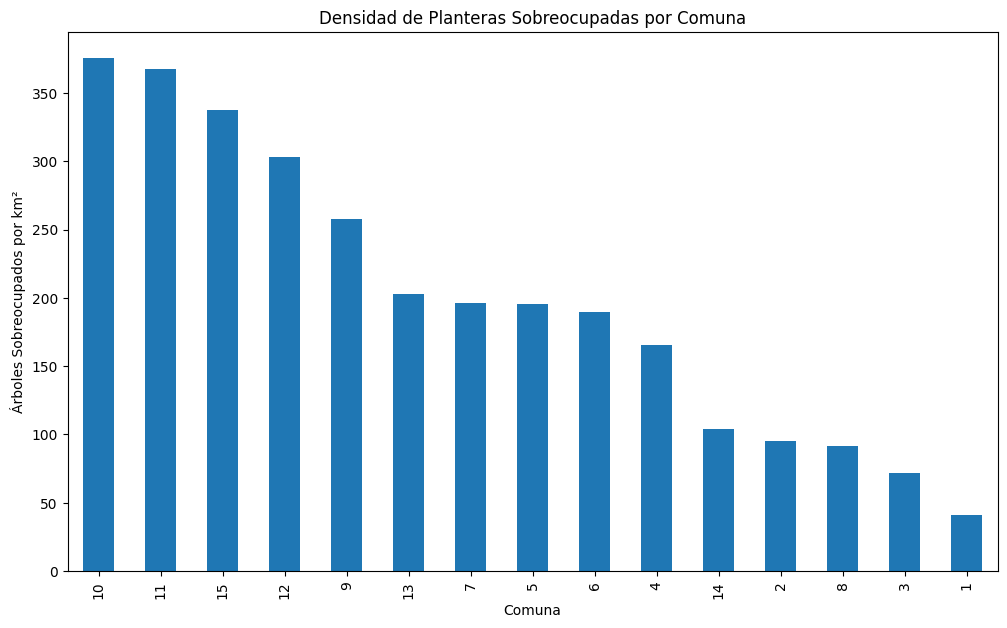

In [ ]:
import pandas as pd
import numpy as np

# Asumo que 'datos_arbolado' es tu DataFrame limpio
# (con 'estado_codificado' y 'comuna')

# --- 1. Crear el Diccionario de Superficies ---
# ¡IMPORTANTE! Debes reemplazar estos valores con los que encontraste en Wikipedia.
# Pongo valores de ejemplo. Asegúrate de que las claves (1, 2, 3...)
# coincidan con los números de comuna de tu DataFrame.
diccionario_superficies = {
    1: 17.4,
    2: 6.1,
    3: 6.3,
    4: 12.4,
    5: 6.7,
    6: 6.8,
    7: 12.4,
    8: 21.9,
    9: 16.6,
    10: 12.7,
    11: 14.1,
    12: 15.6,
    13: 14.6,
    14: 19.1,
    15: 11.3
}

# --- 2. Calcular los Conteos por Comuna ---
# Contamos el total de árboles por comuna
conteo_total = datos_arbolado['comuna'].value_counts()

# Contamos solo los árboles "sobreocupados" (código 3) por comuna
conteo_problema = datos_arbolado[datos_arbolado['estado_plantera'] == 3]['comuna'].value_counts()


# --- 3. Crear un DataFrame de Análisis por Comuna ---
# Combinamos los conteos en un nuevo DataFrame
df_comunas = pd.DataFrame({
    'total_arboles': conteo_total,
    'sobreocupadas': conteo_problema
})

# Llenamos con 0 las comunas que no tengan árboles sobreocupados
df_comunas['sobreocupadas'] = df_comunas['sobreocupadas'].fillna(0)

# --- 4. Mapear la Superficie (El paso clave) ---
# Usamos .map() para asignar a cada comuna su superficie desde el diccionario
df_comunas['superficie_km2'] = df_comunas.index.map(diccionario_superficies)

# --- 5. Calcular los Ratios ---
# ¡Aquí creas tus nuevas variables!
df_comunas['densidad_total_arboles'] = df_comunas['total_arboles'] / df_comunas['superficie_km2']
df_comunas['densidad_problema'] = df_comunas['sobreocupadas'] / df_comunas['superficie_km2']
df_resumen = (
    datos_arbolado.groupby('comuna')
      .agg(
          cantidad_especies=('nombre_cientifico', 'nunique'),
          cantidad_arboles=('nombre_cientifico', 'count')
      )
      .reset_index()
)
df_comunas['cantidad_especies']


# --- 6. Analizar los Resultados ---
# Ordena por la densidad del problema para encontrar los verdaderos "hotspots"
df_comunas_ordenado = df_comunas.sort_values(by='densidad_problema', ascending=False)

print("Análisis de Densidad por Comuna (ordenado por 'densidad_problema'):")
print(df_comunas_ordenado)

# También puedes hacer un gráfico de barras de esto
plt.figure(figsize=(12, 7))
df_comunas_ordenado['densidad_problema'].plot(kind='bar')
plt.title('Densidad de Planteras Sobreocupadas por Comuna')
plt.ylabel('Árboles Sobreocupados por km²')
plt.xlabel('Comuna')
plt.show()

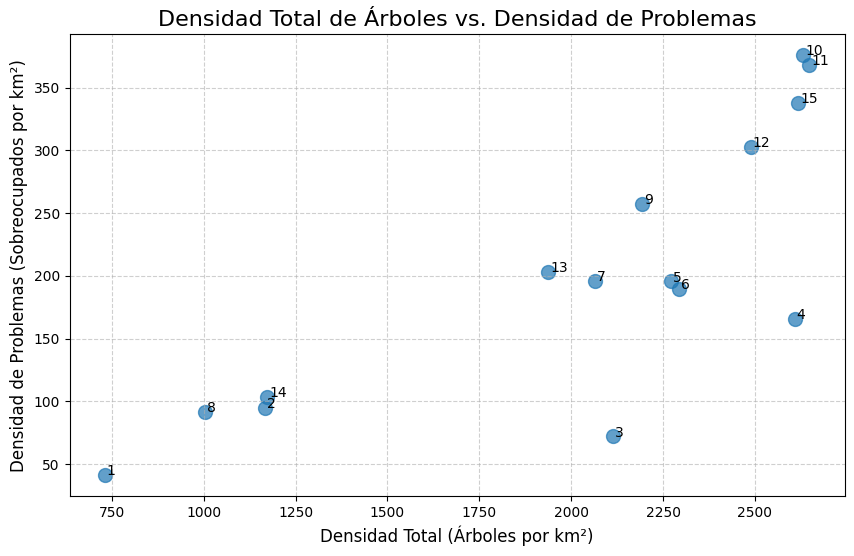

In [63]:
# --- 1. Graficar Densidad Total vs. Densidad de Problema ---
plt.figure(figsize=(10, 6))
plt.scatter(
    df_comunas['densidad_total_arboles'],
    df_comunas['densidad_problema'],
    alpha=0.7,
    s=100 # Puntos más grandes
)

plt.title('Densidad Total de Árboles vs. Densidad de Problemas', fontsize=16)
plt.xlabel('Densidad Total (Árboles por km²)', fontsize=12)
plt.ylabel('Densidad de Problemas (Sobreocupados por km²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# (Opcional) Añadir etiquetas a los puntos
for i, row in df_comunas.iterrows():
    plt.text(row['densidad_total_arboles'] + 5, row['densidad_problema'], str(i))

plt.show()

In [64]:
nivel_estado= datos_arbolado[datos_arbolado['estado_plantera']==3]
nivel_estado['nivel_plantera'].value_counts()

nivel_plantera
1.0    18831
2.0    17864
0.0     1822
Name: count, dtype: int64

In [67]:
# Crear un diccionario {comuna: cantidad_especies}
mapa_especies = df_resumen.set_index('comuna')['cantidad_especies']

# Agregar la columna alineando por el valor de 'comuna'
df_comunas_ordenado['cantidad_especies'] = df_comunas_ordenado['comuna'].map(mapa_especies)
print(df_comunas_ordenado)

    comuna  total_arboles  sobreocupadas  superficie_km2  \
0       10          33421           4773            12.7   
1       11          37340           5185            14.1   
2       15          29587           3817            11.3   
3       12          38818           4726            15.6   
4        9          36405           4277            16.6   
5       13          28287           2961            14.6   
6        7          25608           2432            12.4   
7        5          15224           1310             6.7   
8        6          15591           1287             6.8   
9        4          32346           2051            12.4   
10      14          22417           1980            19.1   
11       2           7115            580             6.1   
12       8          21978           2000            21.9   
13       3          13320            454             6.3   
14       1          12723            716            17.4   

    densidad_total_arboles  densidad_pr

In [65]:
df_resumen = (
    datos_arbolado.groupby('comuna')
      .agg(
          cantidad_especies=('nombre_cientifico', 'nunique'),
          cantidad_arboles=('nombre_cientifico', 'count')
      )
      .reset_index()
)

print(df_resumen)

df_comunas_ordenado = df_comunas_ordenado.merge(
    df_resumen[['comuna', 'cantidad_especies']],
    on='comuna',
    how='left'
)


print(df_comunas_ordenado)

    comuna  cantidad_especies  cantidad_arboles
0        1                145             12723
1        2                105              7115
2        3                115             13320
3        4                229             32346
4        5                180             15224
5        6                184             15591
6        7                221             25608
7        8                249             21978
8        9                267             36405
9       10                229             33421
10      11                229             37340
11      12                233             38818
12      13                213             28287
13      14                173             22417
14      15                245             29587
    comuna  total_arboles  sobreocupadas  superficie_km2  \
0       10          33421           4773            12.7   
1       11          37340           5185            14.1   
2       15          29587           3817            